
# **Import Libraries**



In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix,roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# **Load Dataset**

**Dataset Link:** https://www.kaggle.com/datasets/sahilislam007/online-retail-customer-churn-prediction-dataset

In [2]:
from google.colab import files
uploaded=files.upload()

Saving online_retail_customer_data.csv to online_retail_customer_data.csv


In [120]:
df = pd.read_csv("online_retail_customer_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (9000, 17)


,CustomerID,Age,Gender,Annual_Income_USD,Spending_Score,Membership_Status,Preferred_Payment_Method,Region,Total_Purchases,Avg_Purchase_Value,Last_Purchase_Date,Churn,Satisfaction_Score,Website_Visits_Last_Month,Avg_Time_Per_Visit_Minutes,Support_Tickets_Last_6_Months,Referred_Friends
0,2f8c8c58-4779-4006-aa23-81db3a352da3,56,Female,79228,73,Bronze,Cryptocurrency,Central,17,209.07,2025-05-01,0,2.3,7,3.01,0,1
1,4e6558a6-7f45-4f2a-8dfc-fb05210c5a54,69,Female,23205,65,Silver,Cryptocurrency,Central,21,25.60,2025-04-14,0,2.5,14,5.80,5,2
2,11ab8d14-6dd9-4a49-84cc-963431a8e6fc,46,Male,54929,68,Bronze,Debit Card,Central,25,105.48,2024-11-20,0,4.6,18,5.00,0,0
3,503e4ec0-42c7-4c2d-8cda-a480ad492b4b,32,Female,103384,71,Bronze,PayPal,Central,25,381.95,2024-08-22,1,4.9,20,5.98,5,0
4,841426ba-7371-43b1-9cba-036d07d6c85e,60,Male,53411,11,Silver,PayPal,West,24,319.19,2025-02-05,0,1.2,18,1.67,1,1


**Data Inspection**

In [121]:
df.info()
df.describe()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     9000 non-null   object 
 1   Age                            9000 non-null   int64  
 2   Gender                         9000 non-null   object 
 3   Annual_Income_USD              9000 non-null   int64  
 4   Spending_Score                 9000 non-null   int64  
 5   Membership_Status              9000 non-null   object 
 6   Preferred_Payment_Method       9000 non-null   object 
 7   Region                         9000 non-null   object 
 8   Total_Purchases                9000 non-null   int64  
 9   Avg_Purchase_Value             9000 non-null   float64
 10  Last_Purchase_Date             9000 non-null   object 
 11  Churn                          9000 non-null   int64  
 12  Satisfaction_Score             9000 non-null   f

,0
CustomerID,0
Age,0
Gender,0
Annual_Income_USD,0
Spending_Score,0
Membership_Status,0
Preferred_Payment_Method,0
Region,0
Total_Purchases,0
Avg_Purchase_Value,0


# **Exploratory Data Analysis (EDA)**

**Target Distribution**

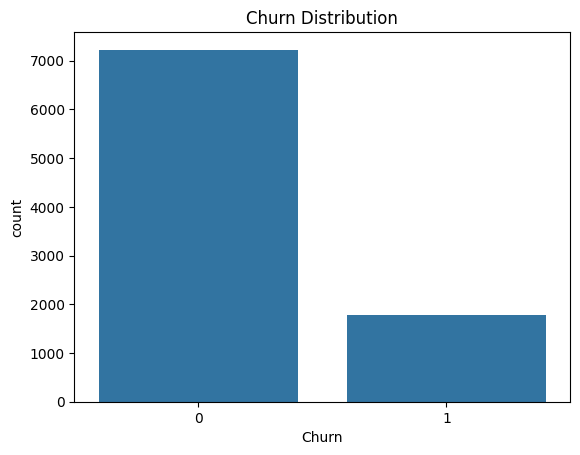

Churn
0    0.802667
1    0.197333
Name: proportion, dtype: float64


In [137]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()
print(df['Churn'].value_counts(normalize=True))

**Numerical Feature Histograms**

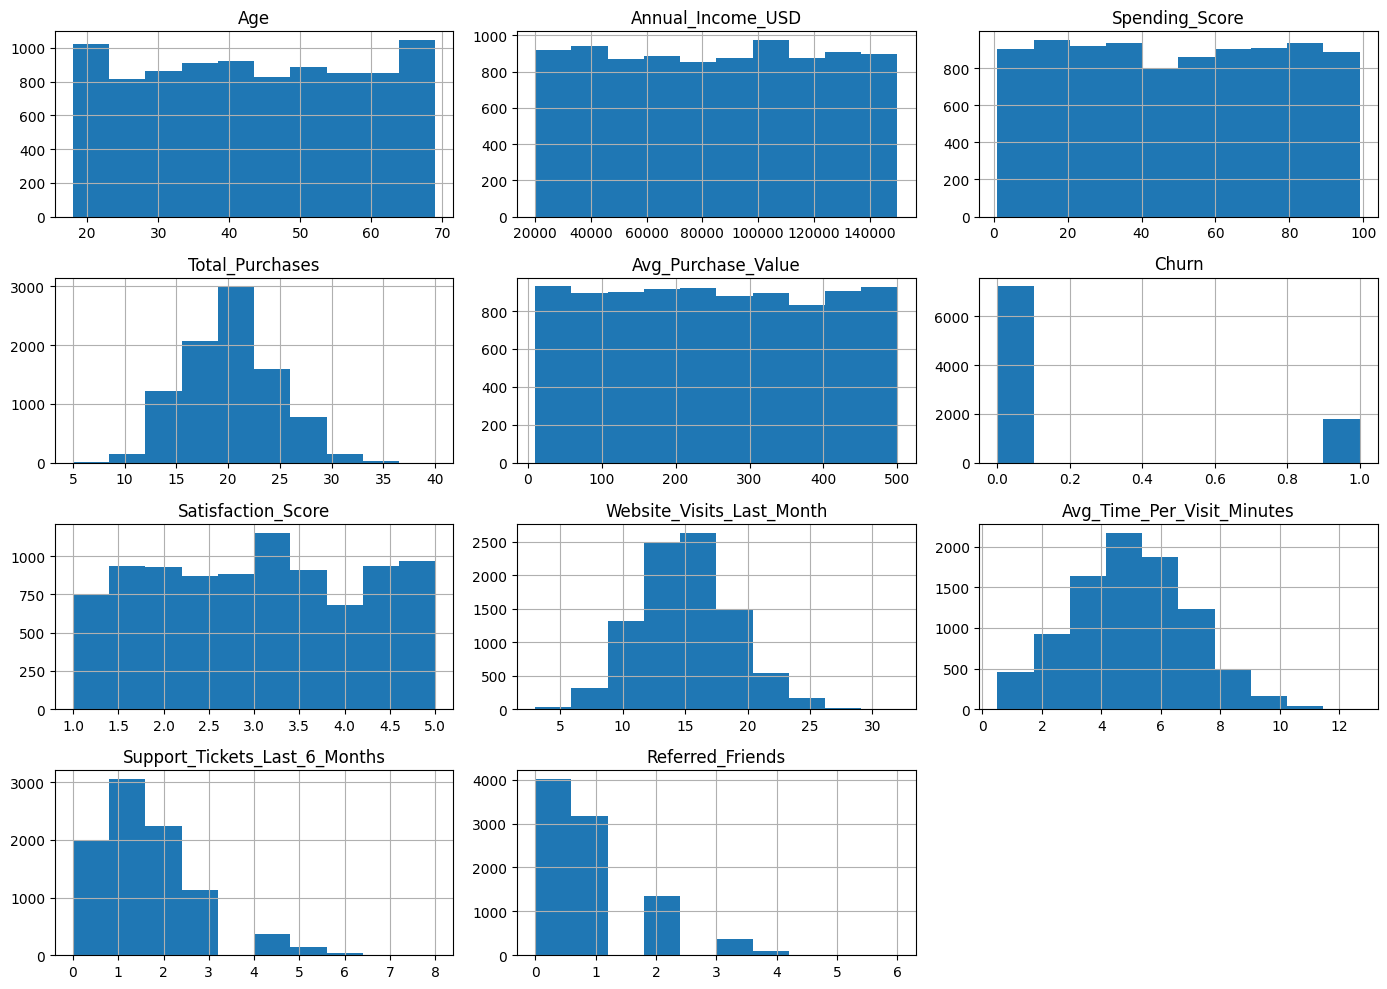

In [131]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].hist(figsize=(14,10))
plt.tight_layout()
plt.show()

**Correlation Heatmap**

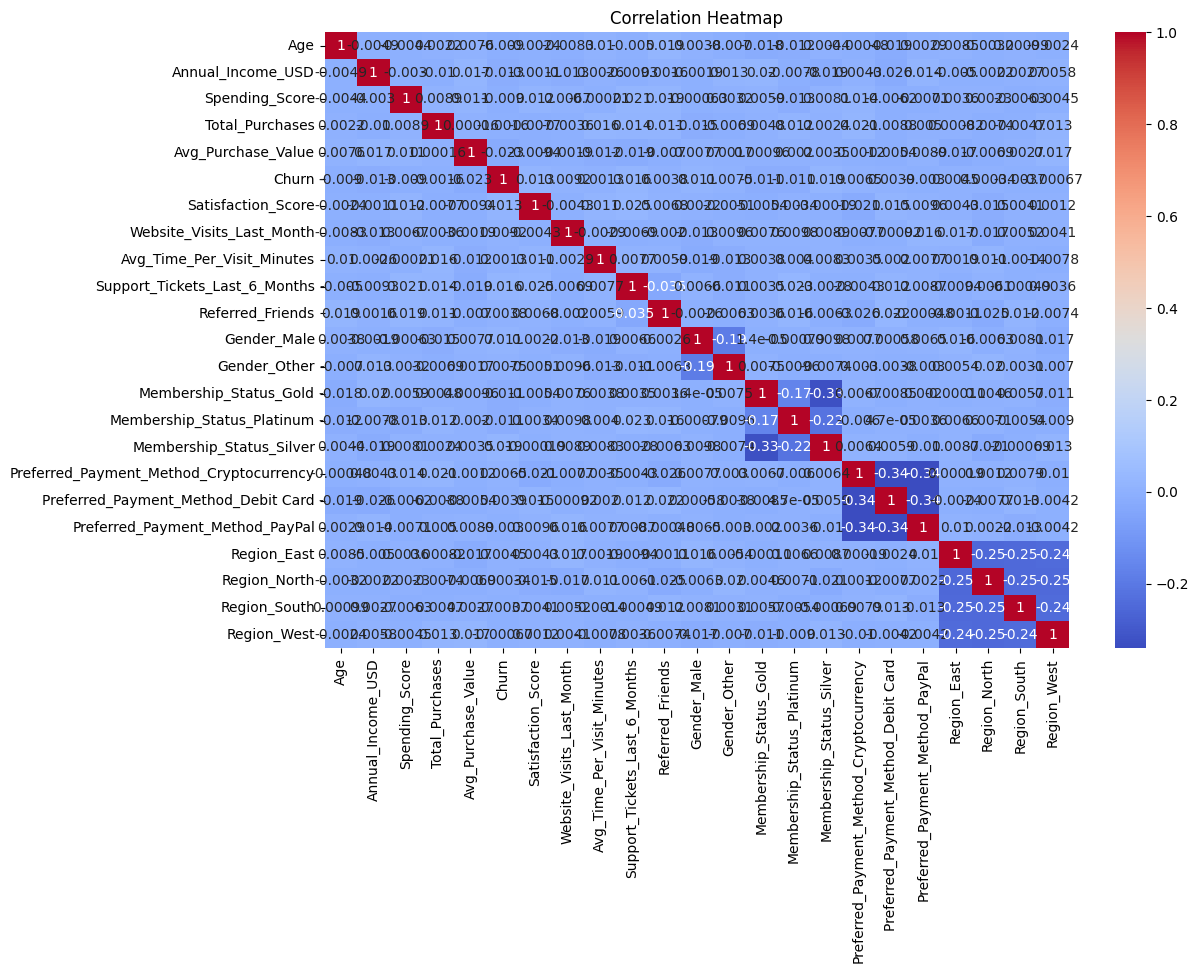

In [138]:
df_corr = df.copy()

# Drop non-numeric identifier columns
df_corr = df_corr.drop(columns=['CustomerID', 'Last_Purchase_Date'], errors='ignore')

# Convert categorical columns to numeric using one-hot encoding
categorical_cols = df_corr.select_dtypes(include='object').columns
df_corr = pd.get_dummies(df_corr, columns=categorical_cols, drop_first=True)

plt.figure(figsize=(12,8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Churn vs Age**

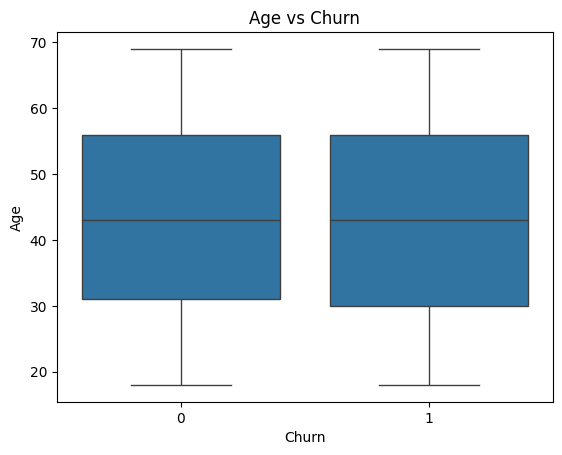

In [141]:
sns.boxplot(x='Churn', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

**Churn vs Satisfaction Score**

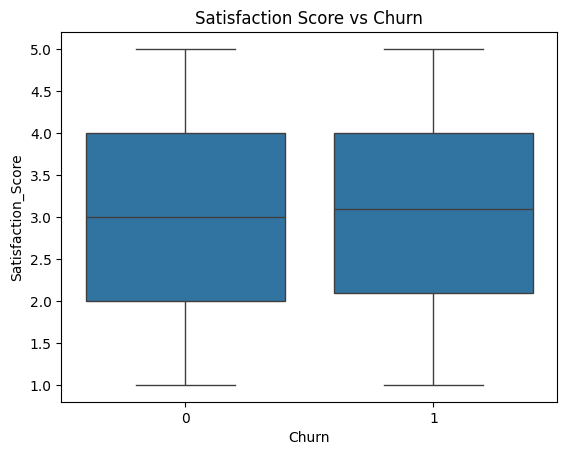

In [143]:
sns.boxplot(x='Churn', y='Satisfaction_Score', data=df)
plt.title("Satisfaction Score vs Churn")
plt.show()

**Churn vs Total Purchases**

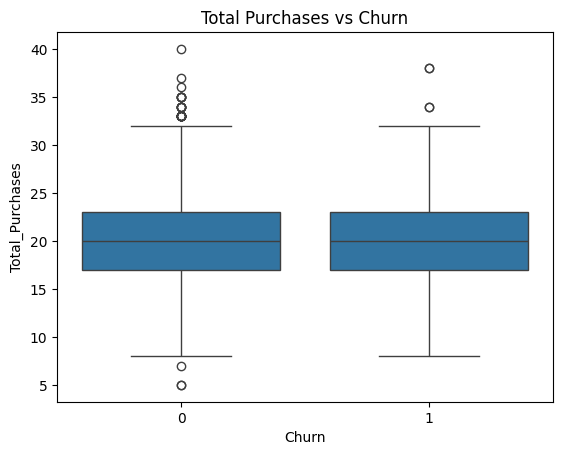

In [144]:
sns.boxplot(x='Churn', y='Total_Purchases', data=df)
plt.title("Total Purchases vs Churn")
plt.show()

**Categorical Comparisons**

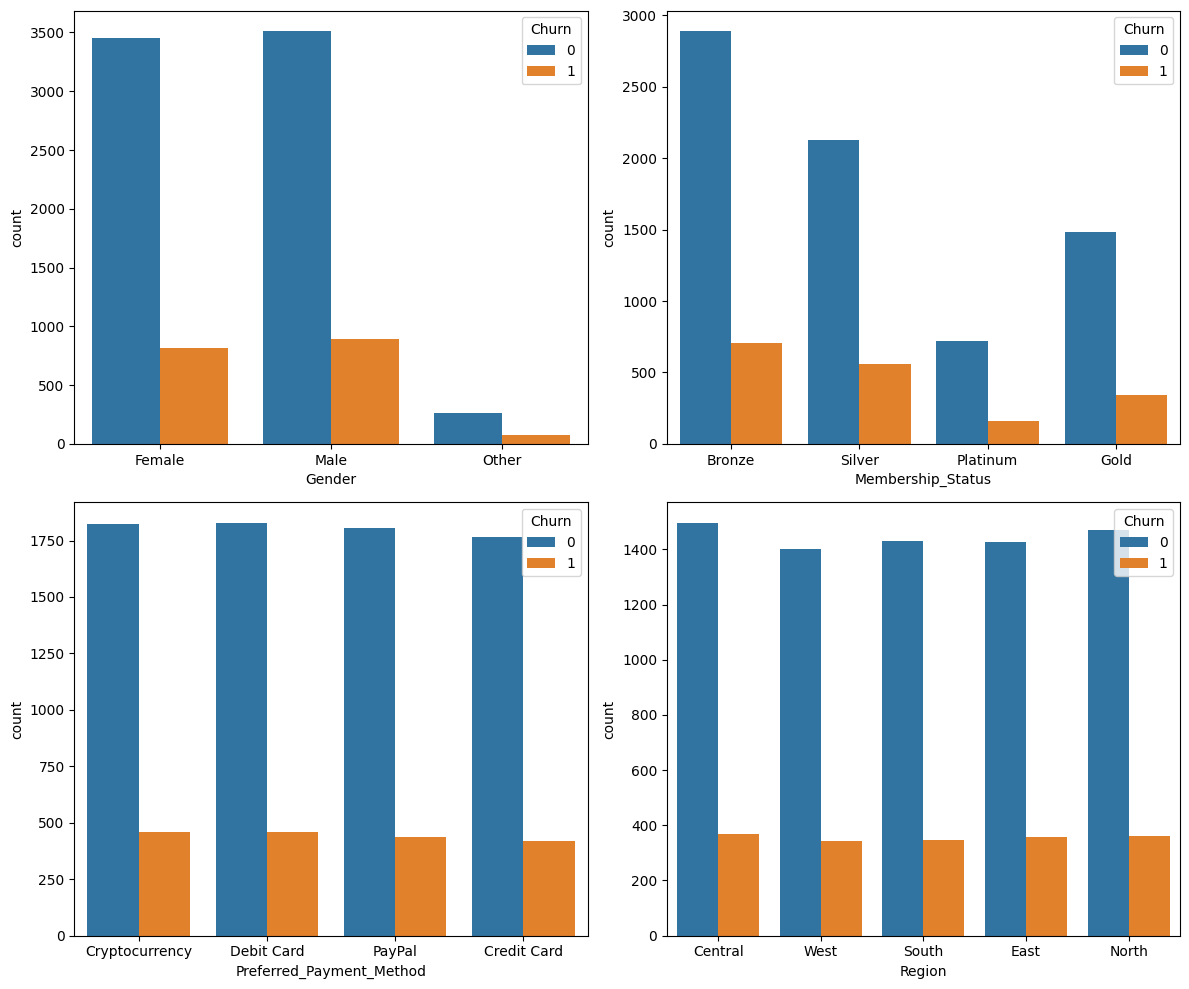

In [145]:
fig, axes = plt.subplots(2,2,figsize=(12,10))

sns.countplot(x='Gender', hue='Churn', data=df, ax=axes[0,0])
sns.countplot(x='Membership_Status', hue='Churn', data=df, ax=axes[0,1])
sns.countplot(x='Preferred_Payment_Method', hue='Churn', data=df, ax=axes[1,0])
sns.countplot(x='Region', hue='Churn', data=df, ax=axes[1,1])

plt.tight_layout()
plt.show()

# **Data Cleaning & Preprocessing**

**Normalize Columns**

In [146]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

Convert Recency

In [147]:
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])

# **Feature Engineering**

**RFM Features**

In [148]:
reference_date = df['last_purchase_date'].max() + pd.Timedelta(days=1)

df['recency'] = (reference_date - df['last_purchase_date']).dt.days
df['frequency'] = df['total_purchases']
df['monetary'] = df['total_purchases'] * df['avg_purchase_value']

**Extra Strong Features for Better Accuracy**

In [149]:
df['engagement_score'] = (
    df['website_visits_last_month'] * df['avg_time_per_visit_minutes']
)

df['complaint_ratio'] = (
    df['support_tickets_last_6_months'] / (df['total_purchases'] + 1)
)

df['loyalty_index'] = (
    df['referred_friends'] * df['satisfaction_score']
)

**Encode Categorical Variables**

In [150]:
df = pd.get_dummies(
    df,
    columns=['gender','membership_status',
             'preferred_payment_method','region'],
    drop_first=True
)

# **Train-Test Split**

In [151]:
X = df.drop(['churn','customerid','last_purchase_date'], axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

## **Feature Scaling (for Logistic Regression)**

In [152]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Train Models**

**Logistic Regression**

In [191]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8026666666666666


**Random Forest**

In [154]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8026666666666666


**XGBoost**

In [185]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=4,
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.8026666666666666


# **Cross-Validation**

In [190]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("LR CV:", cross_val_score(lr, X, y, cv=cv).mean())
print("RF CV:", cross_val_score(rf, X, y, cv=cv).mean())
print("XGB CV:", cross_val_score(xgb_model, X, y, cv=cv).mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LR CV: 0.8026666666666668
RF CV: 0.8027777777777777
XGB CV: 0.8025555555555556


# **Model Evaluation**

In [175]:
print("Classification Report - XGBoost")
print(classification_report(y_test, xgb_pred))

print("ROC AUC Score:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

Classification Report - XGBoost
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1806
           1       0.00      0.00      0.00       444

    accuracy                           0.80      2250
   macro avg       0.40      0.50      0.45      2250
weighted avg       0.64      0.80      0.71      2250

ROC AUC Score: 0.5311324613650196


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Confusion Matrix**

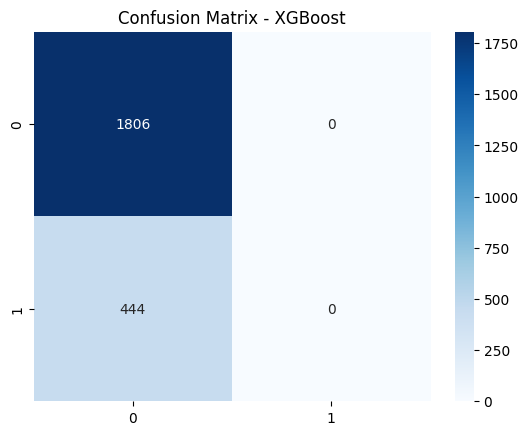

In [176]:
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.show()

# **Feature Importance**

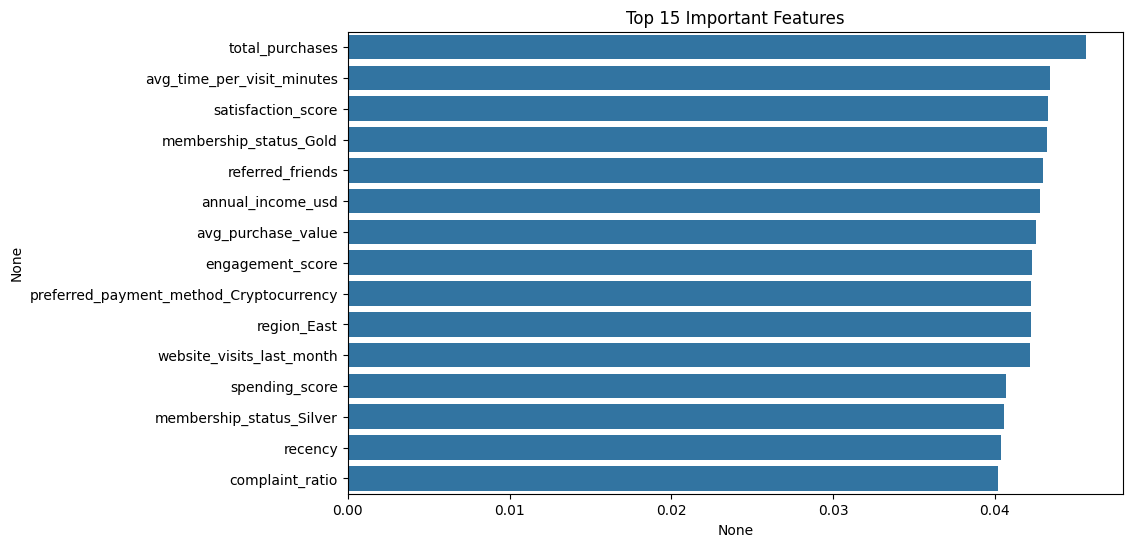

In [177]:
importances = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances[:15], y=importances.index[:15])
plt.title("Top 15 Important Features")
plt.show()

# **ROC curve**

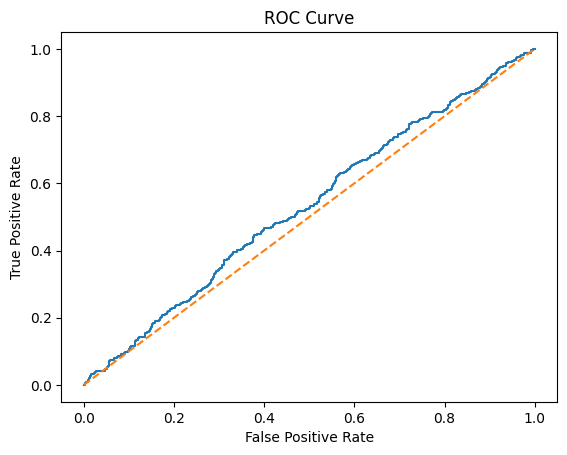

In [178]:
fpr, tpr, thresholds = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# **SHAP**

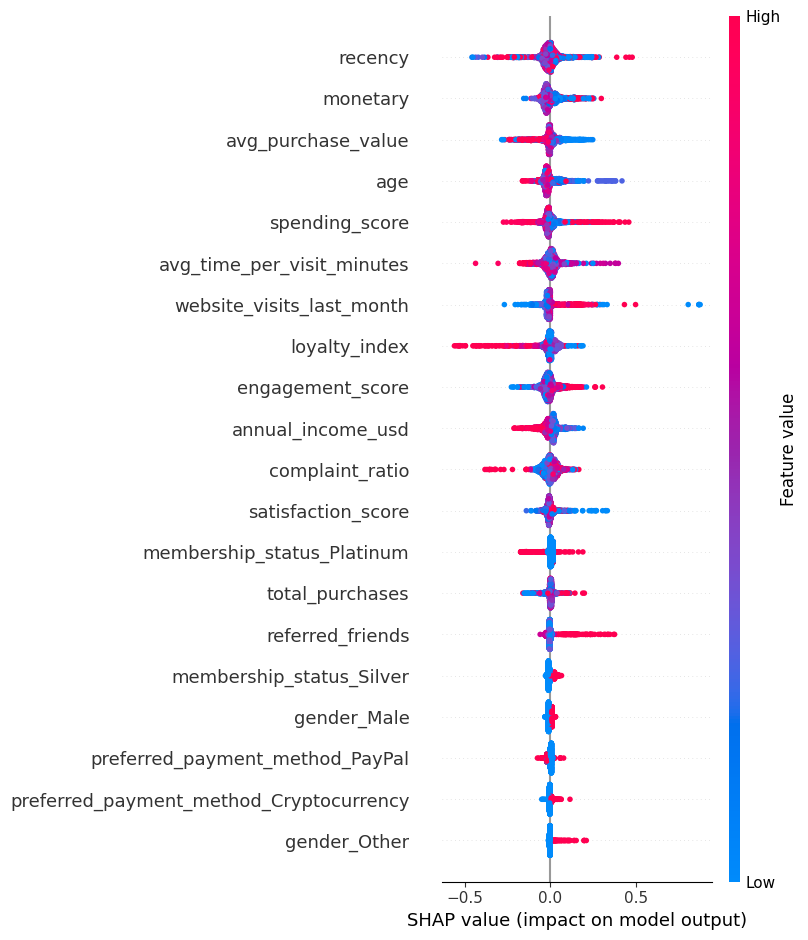

In [186]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

# **Save Model & Scaler**

In [179]:
import joblib

joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

**Download**

In [180]:
files.download("xgb_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>